# Dataset Curation 

some of our dft calculations could have gone wrong. The way to filter this is through the E-V curves for each sample. 

# 
- input : non curated bs
- output: curated bs regarding ev curves

TODO: bopio and bopcal needed for featurizer ! separate package for bopfox ?

## check ev-curves for goodness

In [1]:
import sys
dataset = 'Fe-Mo'  #'Cr-Co-W'
atoms = dataset.split('-')
from Tools.DatasetTools.EVCurvesTools import *
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
import pickle
import os

In [2]:
from scipy.optimize import curve_fit

In [3]:
from ase.eos import EquationOfState, birchmurnaghan

In [4]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=26)
plt.rc('xtick', labelsize=26)
plt.rc('ytick', labelsize=26)
plt.rc('axes', labelsize=30)
from matplotlib.lines import Line2D

In [5]:
make_plots = False

In [6]:
def get_key_for_curves(EVC: pd.core.series.Series, key='str') -> pd.core.series.Series:
    r2 = {}
    for index, data in EVC.items():
        r2[index]={}
        for params, curve in data.items():
            r2[index].update({params: curve[key]})
    return pd.Series(r2)
    

In [7]:
PBS = pd.read_pickle(os.path.join(dataset, 'ParsedBriefsummary.pkl'))

FileNotFoundError: [Errno 2] No such file or directory: 'Fe-Mo/ParsedBriefsummary.pkl'

In [8]:
PBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,-9.322212,1.852201,201.600181,13.586717,12.773585,10.141509,22.915094,0.504702,0.495298
std,0.732151,0.355460,403.869926,1.819627,10.545335,9.251248,13.374809,0.287006,0.287006
min,-10.932826,1.000000,-6867.530562,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,-9.906741,2.000000,207.519474,12.319543,5.000000,3.000000,13.000000,0.289187,0.266667
50%,-9.323460,2.000000,238.101953,13.626611,10.000000,8.000000,24.000000,0.500000,0.500000
75%,-8.831789,2.000000,259.693702,14.900559,17.000000,14.000000,30.000000,0.733333,0.710813
max,-7.780040,2.000000,420.901429,17.320677,53.000000,52.000000,53.000000,1.000000,1.000000


<AxesSubplot:ylabel='Frequency'>

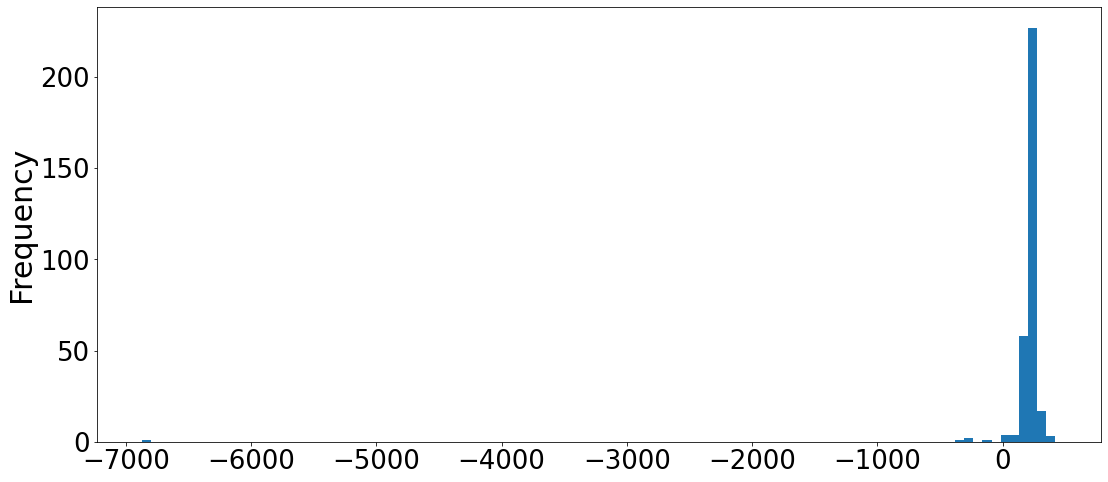

In [9]:
PBS.B0.plot.hist(bins=100)

## Investigate ev-curves

In [10]:
fittedcurvesloc = os.path.join(dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(dataset,'evcurves.json' )
goodnessloc = os.path.join(dataset, 'goodness.json')
force = True

In [11]:
Mo_R = 'Mo_sv53.R.NM'

In [12]:
Fe_R = 'Fe_pv53.R.NM'

In [13]:
if not os.path.exists(fittedcurvesloc) or force:
    if True : #not os.path.exists(evcurvesloc) or force:
        print('redoing')

        EV = Evcurves(Indexes = PBS.index, atoms=dataset.split(), dataset = dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = PBS['deltak'], encuts = PBS['encut'])
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fiteos, r2  = get_goodness(EVcurves, r2tol = 1e-6)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fiteos)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc)
else:
    print('B')
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')
    R2 = get_key_for_curves(EVcurves, 'r2')
    Goodness = get_key_for_curves(EVcurves, 'IsGood')
    Fits = get_key_for_curves(EVcurves, 'fit')

redoing


  0%|          | 0/318 [00:00<?, ?it/s]

  0%|          | 0/318 [00:00<?, ?it/s]

In [14]:
Febcc = 'Fe_pv1.bcc.FM'

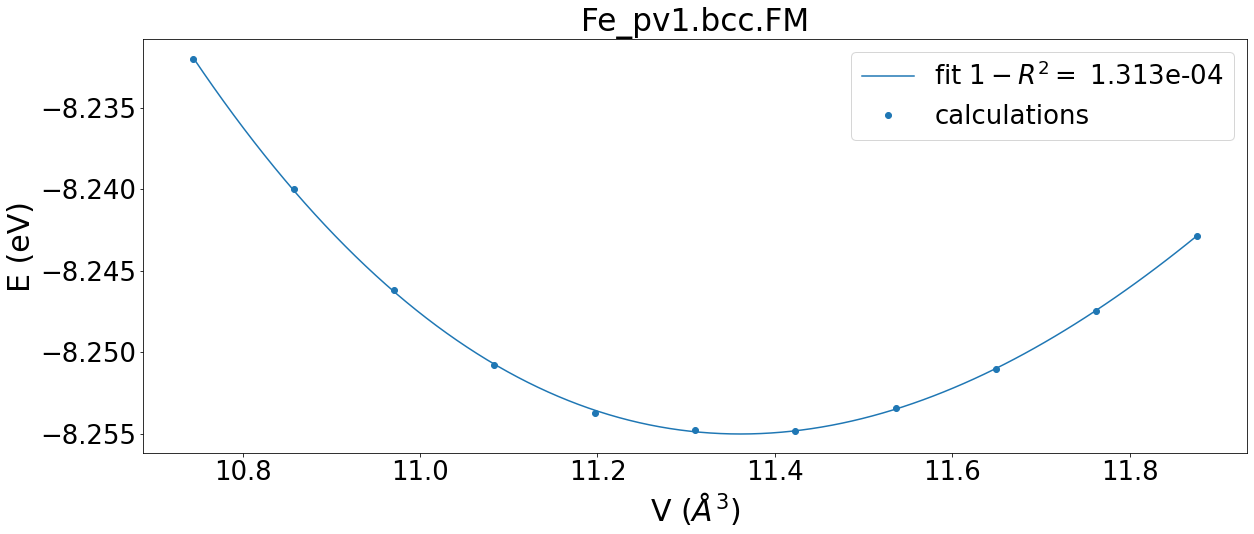

In [15]:
figs, axs = plot_curves(EVcurves[[Febcc]], Fits[[Febcc]], R2[[Febcc]])

In [16]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [17]:
EVcurves_df.index

Index(['Fe_pv8Mo_sv22.sigma-BBABB.FM', 'Fe_pv10Mo_sv20.sigma-ABBAB.FM',
       'Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv3Mo_sv10.mu-ABBBA.FM',
       'Fe_pv5Mo_sv24.chi-AABB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv1Mo_sv3.D03-AB3.NM', 'Fe_pv6Mo_sv18.C36-BBBBA.NM',
       'Fe_pv6Mo_sv18.C36-BBBBA.FM', 'Fe_pv2Mo_sv11.mu-BBABB.NM',
       ...
       'Fe_pv30.sigma.FM', 'Fe_pv1.bcc.FM', 'Fe_pv2.bcc-cubic.FM',
       'Fe_pv6Mo_sv2.A15-AB.NM', 'Fe_pv16Mo_sv8.C36-ABBAA.NM',
       'Fe_pv4Mo_sv2.C15-A2B.FM', 'Fe_pv2Mo_sv4.C15-AB2.FM',
       'Fe_pv8Mo_sv16.C36-BAABB.NM', 'Fe_pv4Mo_sv9.mu-BBBAA.FM',
       'Fe_pv14Mo_sv16.sigma-AABBA.FM'],
      dtype='object', length=317)

In [18]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [19]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [20]:
Better_evcurves = {}

In [21]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [22]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [23]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [24]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [25]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

In [26]:
fit_results_df

,E_murn,B_murn,Bdev_murn,V_murn
Fe_pv8Mo_sv22.sigma-BBABB.FM,-10.004508,224.504766,7.261221,14.954790
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-10.006897,237.945535,4.214880,14.130620
Fe_pv4Mo_sv20.C36-ABBBB.FM,-10.007837,204.312645,4.333180,16.270956
Fe_pv3Mo_sv10.mu-ABBBA.FM,-10.008460,310.905451,-36.764476,15.362713
Fe_pv5Mo_sv24.chi-AABB.FM,-10.015010,216.131543,3.519924,15.750987
...,...,...,...,...
Fe_pv4Mo_sv2.C15-A2B.FM,-9.135293,177.930697,-2.191295,12.307032
Fe_pv2Mo_sv4.C15-AB2.FM,-9.455656,175.245844,4.106883,15.886094
Fe_pv8Mo_sv16.C36-BAABB.NM,-9.611603,232.376504,4.183038,14.705893
Fe_pv4Mo_sv9.mu-BBBAA.FM,-9.612627,207.354253,4.060334,15.244654


Text(0.5, 1.0, '63 Good Samples')

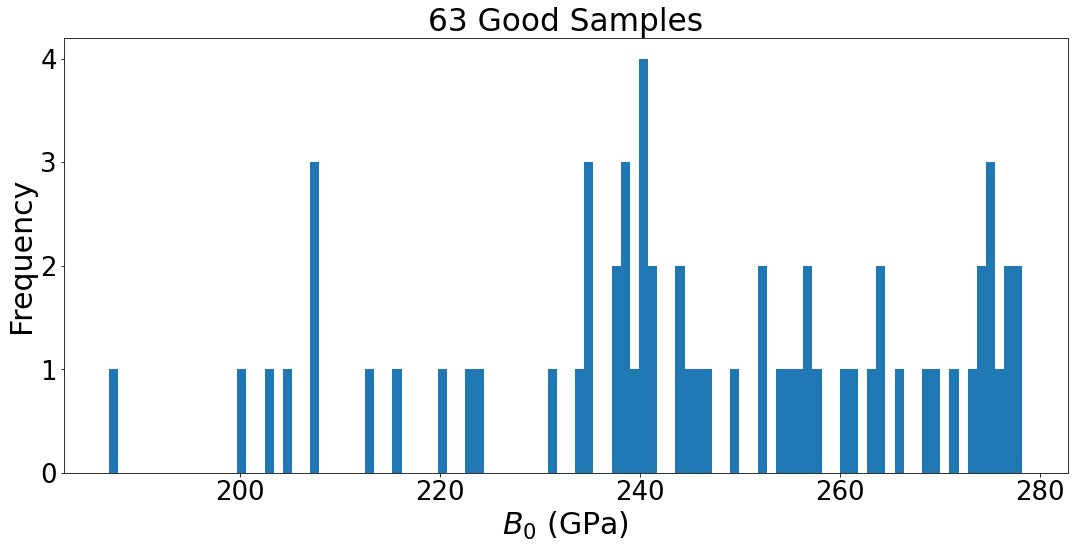

In [27]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [28]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [29]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [30]:
Better_evcurves_df.index.difference(PBS.index)

Index([], dtype='object')

In [31]:
PBS.index.difference(Better_evcurves_df.index)

Index(['Fe_pv5Mo_sv8.mu-ABBAA.NM'], dtype='object')

In [32]:
indexofbadsamples

Index(['Fe_pv1.bcc.FM', 'Fe_pv1.bcc.NM', 'Fe_pv1.fcc.FM',
       'Fe_pv10Mo_sv14.C36-ABBAB.FM', 'Fe_pv10Mo_sv14.C36-ABBAB.NM',
       'Fe_pv10Mo_sv14.C36-ABBBA.FM', 'Fe_pv10Mo_sv14.C36-ABBBA.NM',
       'Fe_pv10Mo_sv14.C36-BABAB.FM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.FM',
       ...
       'Mo_sv24.C36.FM', 'Mo_sv29.chi.FM', 'Mo_sv29.chi.NM',
       'Mo_sv30.sigma.FM', 'Mo_sv4.fcc-cubic.FM', 'Mo_sv4.fcc-cubic.NM',
       'Mo_sv6.C15.FM', 'Mo_sv6.C15.NM', 'Mo_sv8.A15.FM', 'Mo_sv8.A15.NM'],
      dtype='object', length=254)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


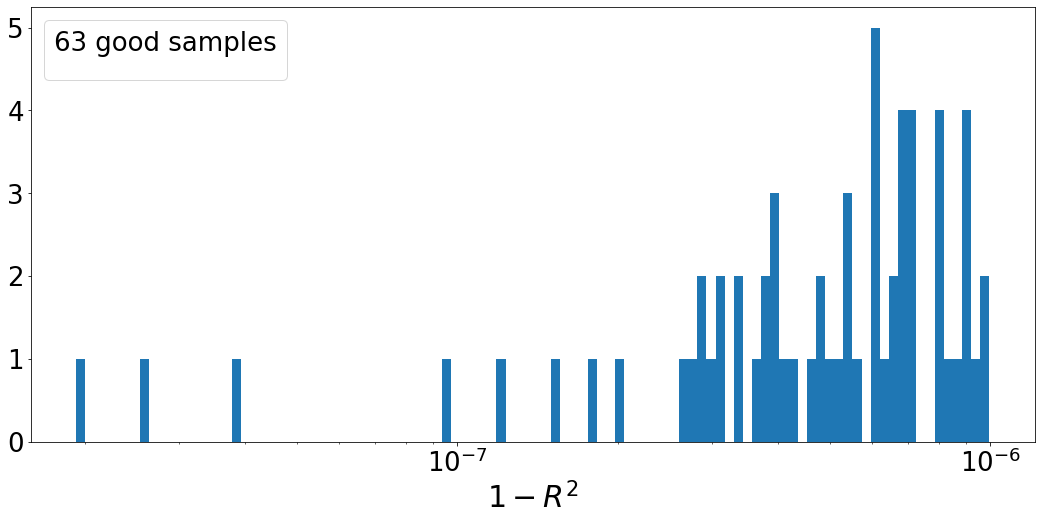

In [33]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

Text(0, 0.5, '$B_0$ from briefsummaries')

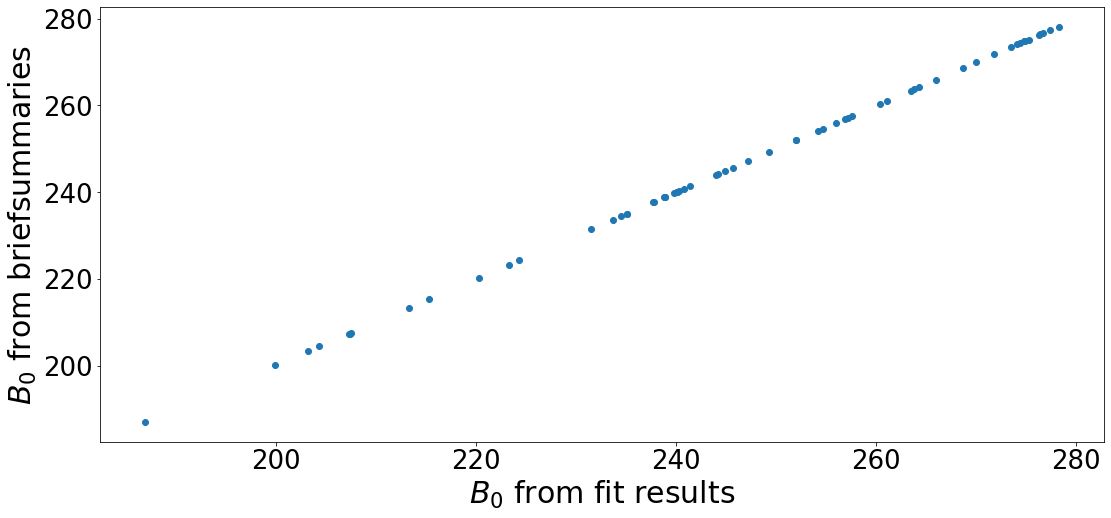

In [34]:
fig, ax = plt.subplots()
ax.plot(fit_results_df.B_murn[indexofgoodsamples], PBS.B0[indexofgoodsamples], 'o')
ax.set_xlabel(r'$B_0$ from fit results')
ax.set_ylabel(r'$B_0$ from briefsummaries')

# Differences between fits and available data for bad samples

In [35]:
diff_fit_to_dataset = ((PBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})

In [36]:
diff_fit_to_dataset['E0'] = ((PBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [37]:
diff_fit_to_dataset['V0'] = ((PBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

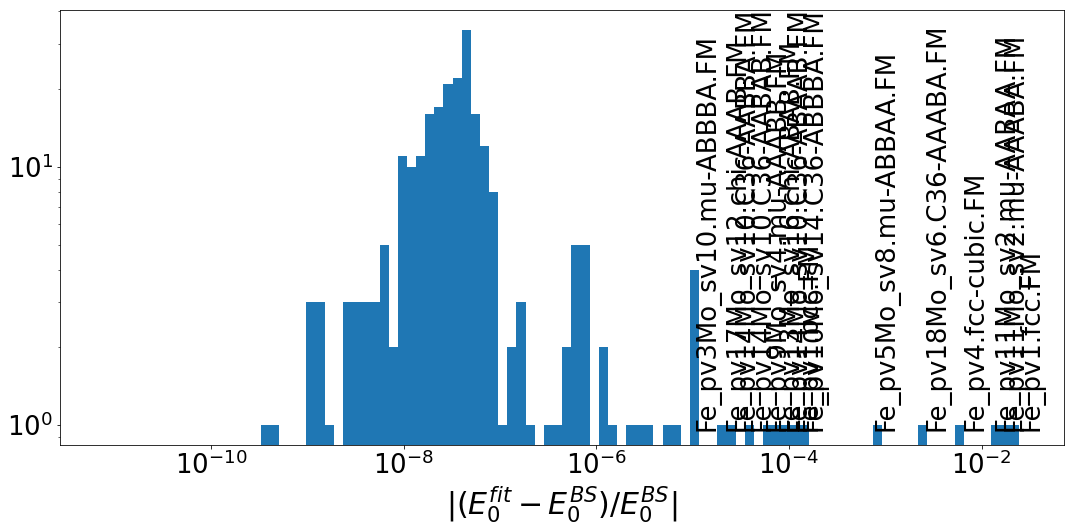

In [38]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

Text(0.5, 0, '$|(V_0 ^{fit} - V_0 ^{BS})/V_0^{BS}|$')

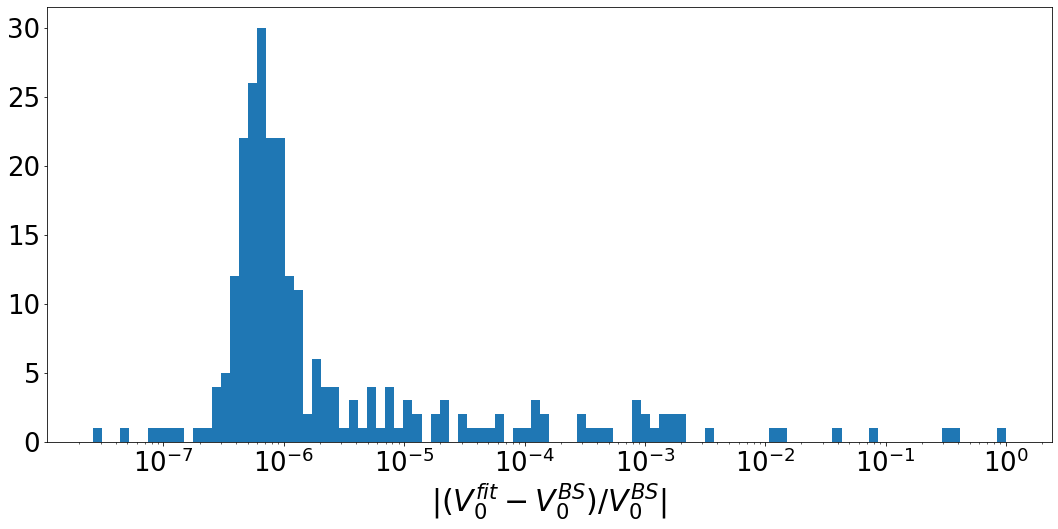

In [39]:
#large_diff_V0 = diff_fit_to_dataset.query('V0 > 0.2e-3').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.V0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = ax.hist(diff_fit_to_dataset.V0, bins=logbins)
#for index in large_diff_V0:
#    x = diff_fit_to_dataset.V0[index]
#    y = 1
#    ax.annotate(index, (x, y), rotation=90)
plt.xscale('log')
plt.xlabel(r'$|(V_0 ^{fit} - V_0 ^{BS})/V_0^{BS}|$')

Text(0.5, 0, '$|(B_0 ^{fit} - B_0 ^{BS})/B_0^{BS}|$')

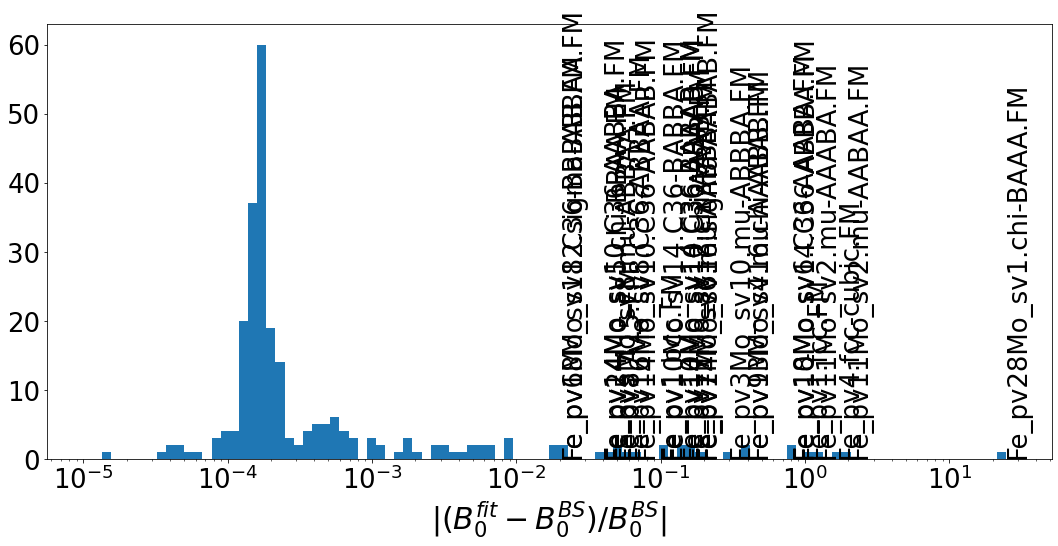

In [40]:
large_diff_B0 = diff_fit_to_dataset.query('B0 > 0.2e-1').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.B0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.B0, bins=logbins)
for index in large_diff_B0:
    x = diff_fit_to_dataset.B0[index]
    y = 1
    ax.annotate(index, (x, y), rotation=90)
plt.xscale('log')
plt.xlabel(r'$|(B_0 ^{fit} - B_0 ^{BS})/B_0^{BS}|$')

In [41]:
if make_plots:
    figs, axs = plot_curves(EVcurves[large_diff_B0], Fits[large_diff_B0], R2[large_diff_B0])
    for fig, ax  in zip(figs, axs):
        index = ax.title.get_text()
        V0, E0 = PBS[['V0','E0']].loc[index].values
        for paramspec, fitsparam in Fits[index].items():
            break
        e0 = fitsparam[0]
        v0 = fitsparam[-1]
    #    ax = ax.inset_axes([0.45, 0.3, 0.2, 0.2])
        ax.plot([V0], [E0], 'dk', label='value in briefsummary')
        ax.plot([v0],[e0], 'sb', label = 'value from fit')
        ax.legend()

# correct bad samples with new E0, B0, E0

# Test On obvious ones

In [42]:
Febcc = 'Fe_pv1.bcc.FM'

In [43]:
Better_evcurves_df.loc[Mo_R].IsGood

True

In [44]:
Better_evcurves_df.loc['Fe_pv1.bcc.FM'].IsGood

False

([<Figure size 1296x576 with 1 Axes>, <Figure size 1296x576 with 1 Axes>],
 [<AxesSubplot:title={'center':'Mo_sv53.R.NM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>,
  <AxesSubplot:title={'center':'Fe_pv1.bcc.FM'}, xlabel='V ($\\AA ^3$)', ylabel='E (eV)'>])

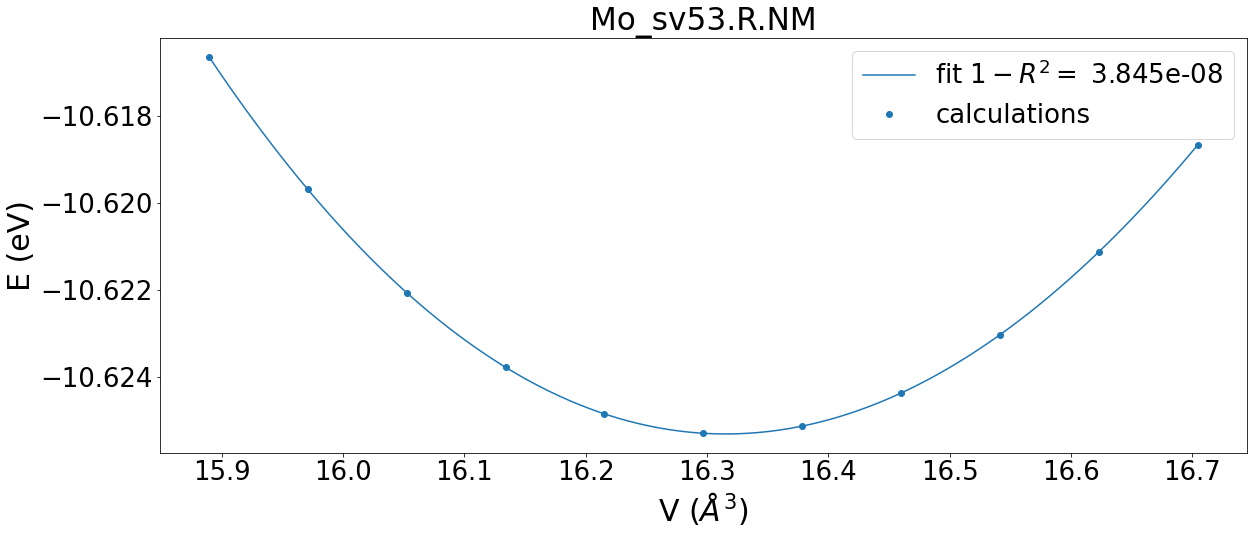

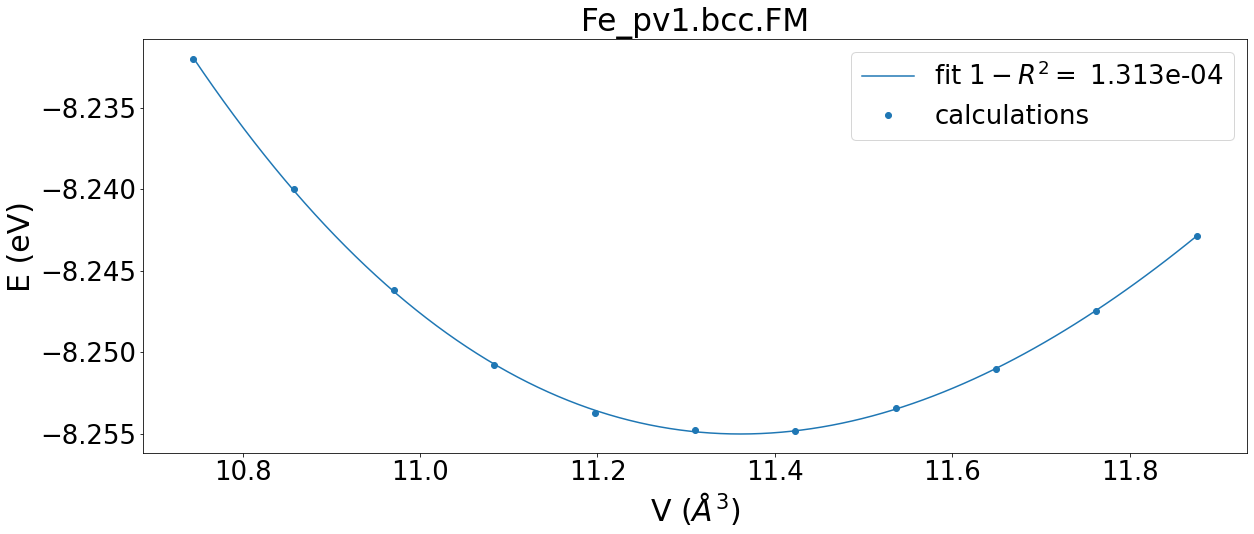

In [45]:
plot_curves(EVcurves[[Mo_R, Febcc]], Fits[[Mo_R, Febcc]], R2[[Mo_R, Febcc]])

In [46]:
GoodBS = PBS.loc[indexofgoodsamples]
GoodBS = GoodBS[~GoodBS.index.str.contains('sigma-BABBB.FM|sigma-AABBB.FM|mu-BBBBA.FM')]
BadBS = PBS.loc[indexofbadsamples]

# Try to correct the bad fits by removing points 

In [47]:
from importlib.machinery import SourceFileLoader

In [48]:
len(PBS)

318

In [49]:
len(indexofgoodsamples)

63

In [50]:
len(indexofbadsamples)

254

In [51]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-6
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (r2>1-tol) & common_sense_evcurve )
        now_is_good.append( (r2>1-tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

  0%|          | 0/254 [00:00<?, ?it/s]

In [52]:
if make_plots:
    for index, fixedevcurve in fixedevcurves.items():
        if index not in large_diff_B0:
            continue
        #ax[0].plot(reducedv[bestcombi], reducede[bestcombi], 'o')
        for paramspec, data in fixedevcurve.items():
            isgood = data['IsGood']
            x =data['evcurve']['V']
            xx = np.linspace(x.min(), x.max(), 100)
            y = data['evcurve']['E']
            thisparams = copy.copy(data['fit'])
            thisparams[1]/=ev_per_angstrom3_to_GPA
            fixed_r2 = data['r2']
            B0 = thisparams[1]#data['fit'][1]
            V0 = thisparams[-1] # data['fit'][-1]
            message = f'fixed curve, $1-R^2$ = {1-fixed_r2:.1e}, $B_0 $= {B0*ev_per_angstrom3_to_GPA:.3f}, Isgood = {isgood}, v0 = {V0:.3f}'
        if not isgood :
            continue
            fig, ax = plot_curves(EVcurves[[index]], Fits[[index]],R2[[index]])
            l = ax[0].plot(xx, birchmurnaghan(xx, *thisparams), '--',label=message)[0]
            ax[0].plot(x, y, 'o', c=l.get_color())
            ax[0].legend()

In [53]:
fixedevcurves

Fe_pv1.bcc.FM                  {'xc=PBE-PAW.E=440.dk=0.016': {'evcurve': {'V'...
Fe_pv1.bcc.NM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1.fcc.FM                  {'xc=PBE-PAW.E=480.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv14.C36-ABBAB.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv10Mo_sv14.C36-ABBAB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
                                                     ...                        
Mo_sv4.fcc-cubic.NM            {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv6.C15.FM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv6.C15.NM                  {'xc=PBE-PAW.E=400.dk=0.014': {'evcurve': {'V'...
Mo_sv8.A15.FM                  {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv8.A15.NM                  {'xc=PBE-PAW.E=400.dk=0.016': {'evcurve': {'V'...
Name: FixedEVcurves, Length: 254, dtype: object

## check new total of good curves

In [54]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [55]:
fixedevcurves_df.shape

(254, 14)

In [56]:
Better_fixedevcurves = {}

In [57]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [58]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [59]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [60]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [61]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [62]:
indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [63]:
len(indexoffixedgoodsamples)

229

In [64]:
indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)

In [65]:
len(indexoffixedbadsamples)

25

In [66]:
PBS.shape

(318, 21)

In [67]:
len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)

292

In [68]:
finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)

In [69]:
finalindexofsamples

Index(['Fe_pv4Mo_sv20.C36-ABBBB.FM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBABB.FM', 'Fe_pv8Mo_sv22.sigma-BBBAB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv4Mo_sv20.C36-BBABB.NM',
       'Fe_pv2Mo_sv10.C14-BAB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Fe_pv4Mo_sv26.sigma-BABBB.NM', 'Fe_pv1Mo_sv12.mu-ABBBB.NM',
       ...
       'Fe_pv4Mo_sv2.C15-A2B.FM', 'Fe_pv6Mo_sv2.A15-AB.NM',
       'Fe_pv8Mo_sv16.C36-BAABB.NM', 'Fe_pv30.sigma.FM', 'Fe_pv4.fcc-cubic.FM',
       'Fe_pv6.C15.FM', 'Mo_sv1.bcc.NM', 'Mo_sv8.A15.NM', 'Mo_sv1.fcc.NM',
       'Mo_sv6.C15.NM'],
      dtype='object', length=292)

In [70]:
fixedGoodBS = PBS.loc[finalindexofsamples]

In [71]:
fixedGoodBS.shape

(292, 21)

# fixed quantities

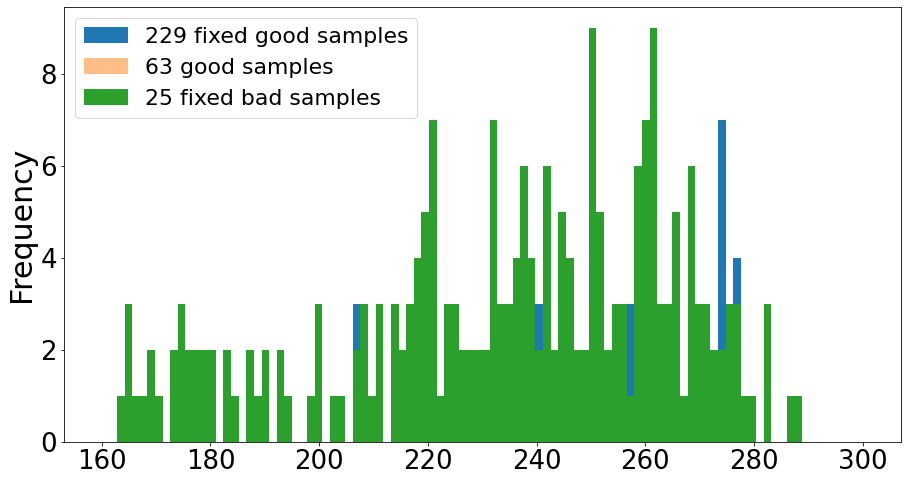

In [72]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

# still some bad samples after trying to fix ! 

In [73]:
len(indexoffixedbadsamples)

25

In [74]:
if make_plots:
    for stilbadsample in indexoffixedbadsamples:
        fig, ax=plot_curves(fixedevcurves[[stilbadsample]], fixedFits[[stilbadsample]], fixedR2[[stilbadsample]])
        ax[0].plot(Better_evcurves_df.loc[stilbadsample]['evcurve']['V'],Better_evcurves_df.loc[stilbadsample]['evcurve']['E'] , 'o', markersize=12, markerfacecolor='None')
        handles, labels = ax[0].get_legend_handles_labels()
        thisb0 = fixed_ev_fit_results_df.B_murn[stilbadsample]
        thisbdev = fixed_ev_fit_results_df.Bdev_murn[stilbadsample]
        labels[0] +=f', B0 = {thisb0:.3f}, Bdev = {thisbdev:.3f}'
        ax[0].legend(handles, labels)

# redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [75]:
fixedGoodBS['E0'].dropna()

Fe_pv4Mo_sv20.C36-ABBBB.FM        -10.007837
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM   -10.020954
Fe_pv2Mo_sv11.mu-BBABB.FM         -10.117556
Fe_pv8Mo_sv22.sigma-BBBAB.NM      -10.141531
Fe_pv2Mo_sv11.mu-BBBBA.NM         -10.146330
                                     ...    
Fe_pv6.C15.FM                      -8.111077
Mo_sv1.bcc.NM                     -10.932826
Mo_sv8.A15.NM                     -10.837504
Mo_sv1.fcc.NM                     -10.511039
Mo_sv6.C15.NM                     -10.565350
Name: E0, Length: 292, dtype: float64

In [76]:
fixedGoodBS['E0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]

In [77]:
fixedGoodBS['V0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]

In [78]:
fixedGoodBS['B0'][indexoffixedgoodsamples] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]

In [79]:
fixedGoodBS.dropna().describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000


In [80]:
fixedGoodBS.shape

(292, 21)

## Remove extra magnetic sampling

First feature to remove from this dataset is the list of samples used form ferrimagnetic phase sampling. This subset is not in the current interest and might bring problems so we remove from datastet.

In [81]:
fixedGoodBS.query('index.str.contains("[UD]+$")')#.loc[['Fe_pv30.sigma.FM', 'Fe_pv30.sigma.NM']]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase


## Obtain some info from indexes

In [82]:
Features = Featurizer(fixedGoodBS)

In [83]:
fixedGoodBS.shape

(292, 21)

# TODo this sould be in tools, as a phase cleaner

In [84]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    fixedGoodBS.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=fixedGoodBS.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

In [85]:
DescriptorsLoc = os.path.join(dataset,'Descriptors')
if not os.path.exists(DescriptorsLoc):
    os.makedirs(DescriptorsLoc)
Target_Class.to_pickle(os.path.join(DescriptorsLoc, 'ClassLabels.pkl'))

In [86]:
fixedGoodBS['Phase'] = Target_Class

In [87]:
fixedGoodBS.describe()

,E0,nelem,B0,V0,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv
count,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,292.000000
mean,-9.347206,1.845890,235.138358,13.582107,12.89726,10.291096,23.188356,0.498634,0.501366
std,0.746336,0.361674,31.685307,1.654945,10.85723,9.537817,13.755429,0.292605,0.292605
min,-10.932821,1.000000,141.243922,10.193528,1.00000,0.000000,1.000000,0.000000,0.000000
25%,-9.955671,2.000000,217.823336,12.275667,4.00000,2.750000,13.000000,0.262500,0.266667
50%,-9.332258,2.000000,240.028922,13.425116,10.00000,8.500000,24.000000,0.500000,0.500000
75%,-8.825165,2.000000,260.406947,14.978348,18.00000,16.000000,30.000000,0.733333,0.737500
max,-7.780036,2.000000,287.828951,16.550514,53.00000,52.000000,53.000000,1.000000,1.000000


# Save good fixed BS 

In [88]:
fixedGoodBS.to_pickle(os.path.join(dataset, "CuratedParsedBriefSummary.pkl") )

# some E-V curves, good and bad

## sample bad

In [89]:
sample_bad_index = BadBS.sample(n=5).index#.append(pd.Index(['Mo_sv53.R.NM'])).unique()

In [90]:
sample_bad = EVcurves[sample_bad_index] #[BadBS.index].dropna().sample(n=min(5, BadBS.shape[0]))

In [91]:
plt.rc('font', size=22)
plt.rc('figure', figsize=(12,8))

In [92]:
sample_bad_r2 = R2[sample_bad.index]

In [93]:
sample_bad_fit = Fits[sample_bad.index]

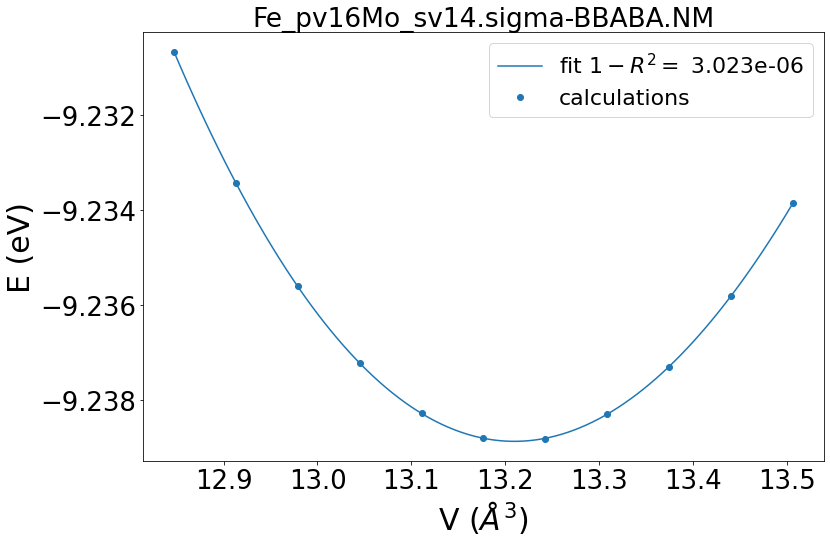

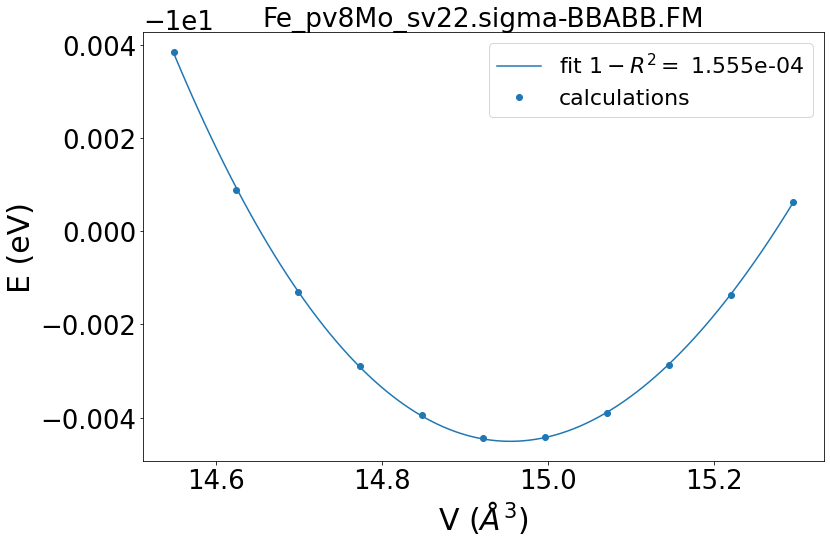

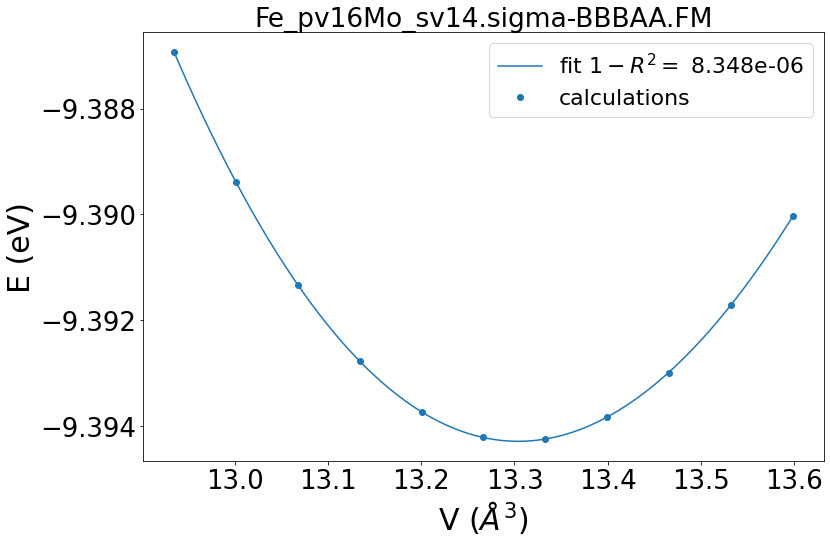

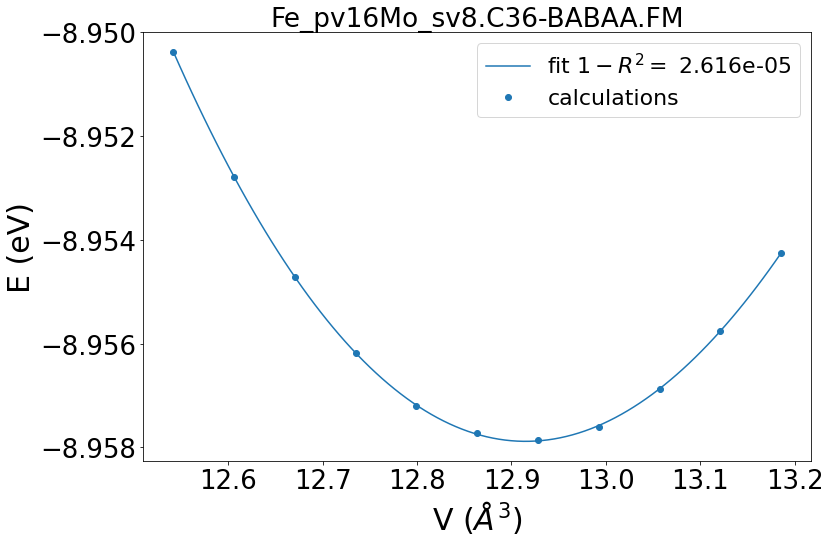

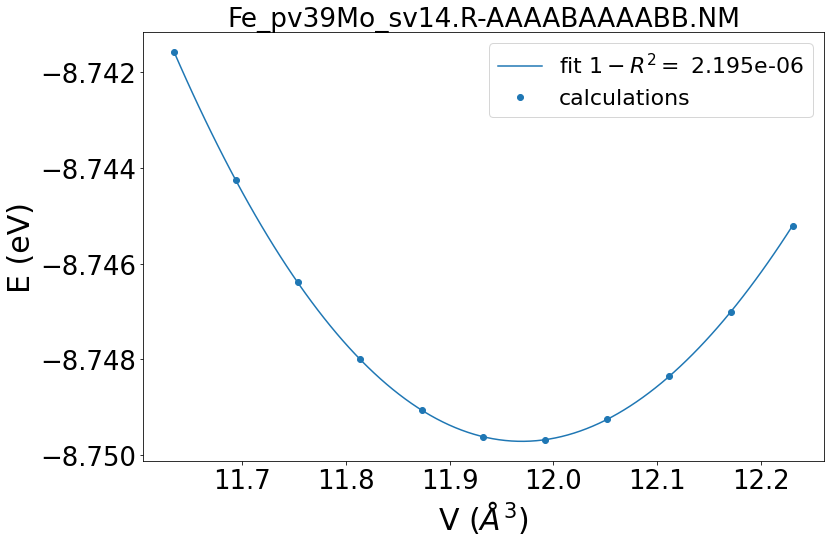

In [94]:
figurecollection, axcollection  = plot_curves(sample_bad, sample_bad_fit, sample_bad_r2)

# Cases of interest

In [95]:
interesting_cases = ['Fe_pv28Mo_sv1.chi-BAAA.FM', 'Fe_pv11Mo_sv2.mu-AAABA.FM', 'Fe_pv1.fcc.FM', 'Fe_pv1.fcc.FM', Mo_R]

In [96]:
Better_evcurves_df.IsGood[interesting_cases]

Fe_pv28Mo_sv1.chi-BAAA.FM    False
Fe_pv11Mo_sv2.mu-AAABA.FM    False
Fe_pv1.fcc.FM                False
Fe_pv1.fcc.FM                False
Mo_sv53.R.NM                  True
Name: IsGood, dtype: bool

In [97]:
Fits.loc[interesting_cases][0]

{'xc=PBE-PAW.E=450.dk=0.020': array([-8.23994851e+00,  7.97575010e-01,  5.13504221e+03,  1.15394111e+01])}

In [98]:
Better_evcurves_df.ev_fit_results[interesting_cases][0]

{'E_murn': -8.240007,
 'V_murn': 11.555812,
 'B_murn': 20.484025,
 'Bdev_murn': 59.173261}

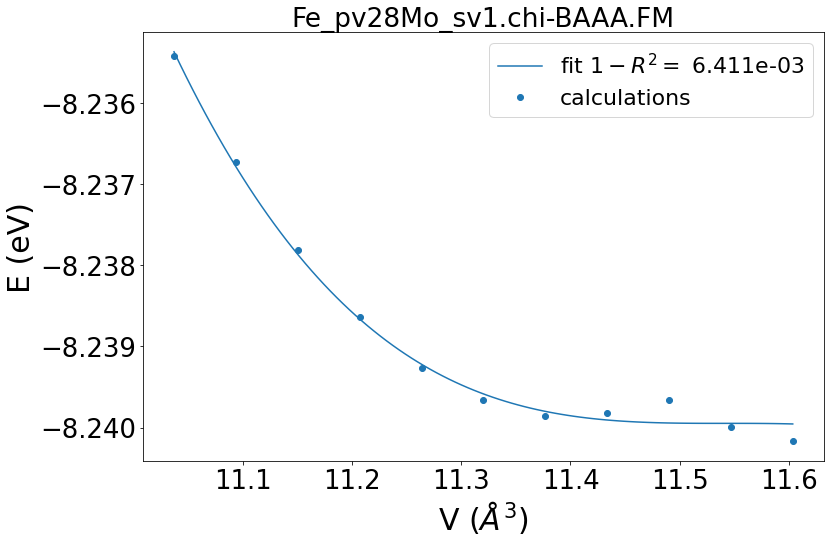

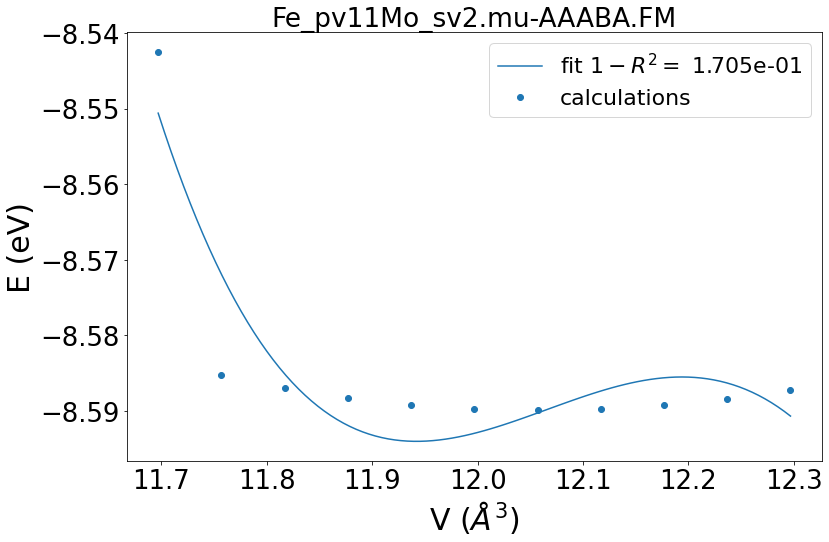

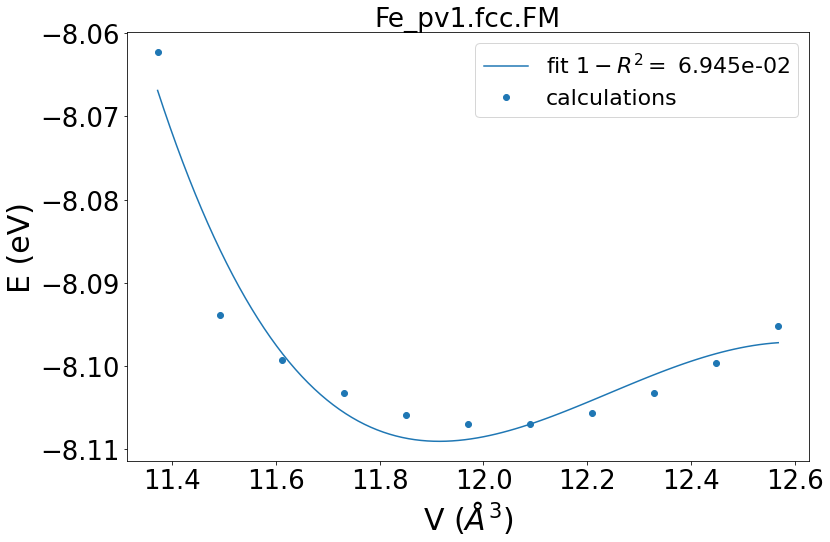

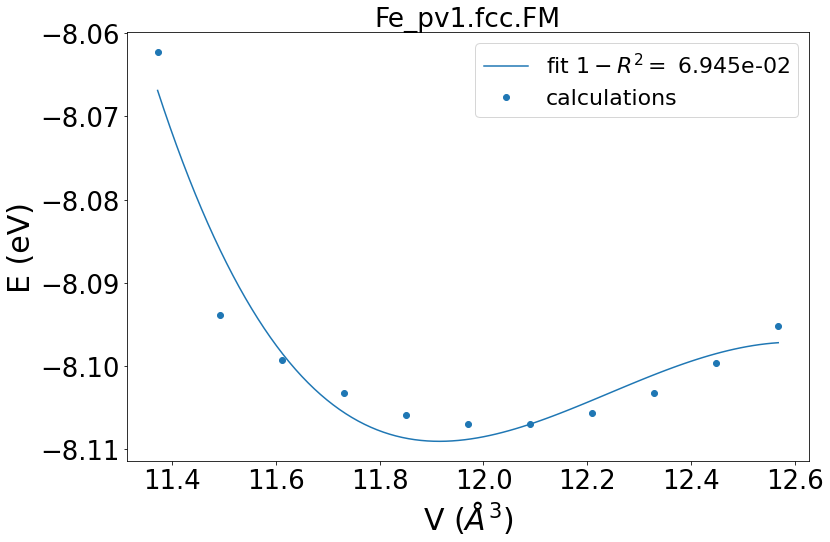

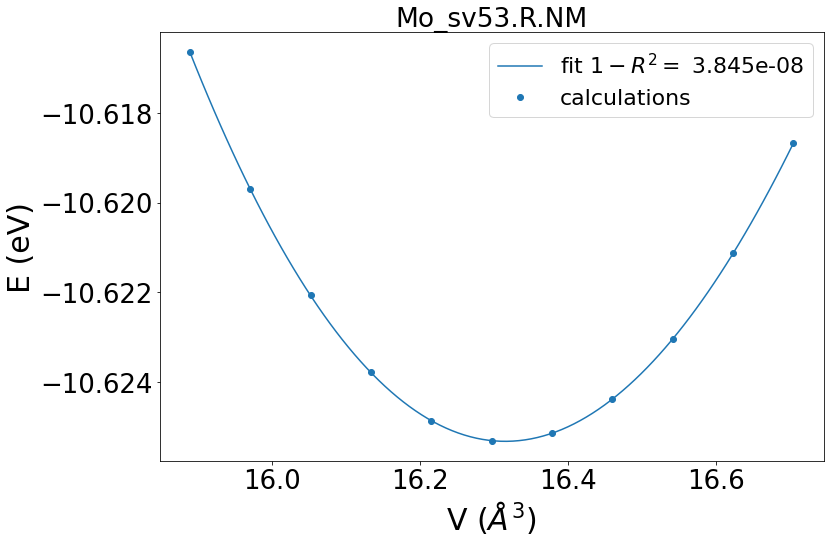

In [99]:
figs, axs = plot_curves(EVcurves[interesting_cases], Fits[interesting_cases], R2[interesting_cases])


# Sample good

In [100]:
sample_good = EVcurves[fixedGoodBS.index].dropna().sample(n=5)

In [101]:
sample_good

Fe_pv22Mo_sv8.sigma-AAABA.FM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv4.C36-ABAAA.NM      {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv1Mo_sv3.L12-AB3.FM         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv7Mo_sv6.mu-AABBB.NM        {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv2.hcp.NM                   {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
dtype: object

In [102]:
sample_good_r2 = R2[sample_good.index]

In [103]:
sample_good_fit = Fits[sample_good.index]

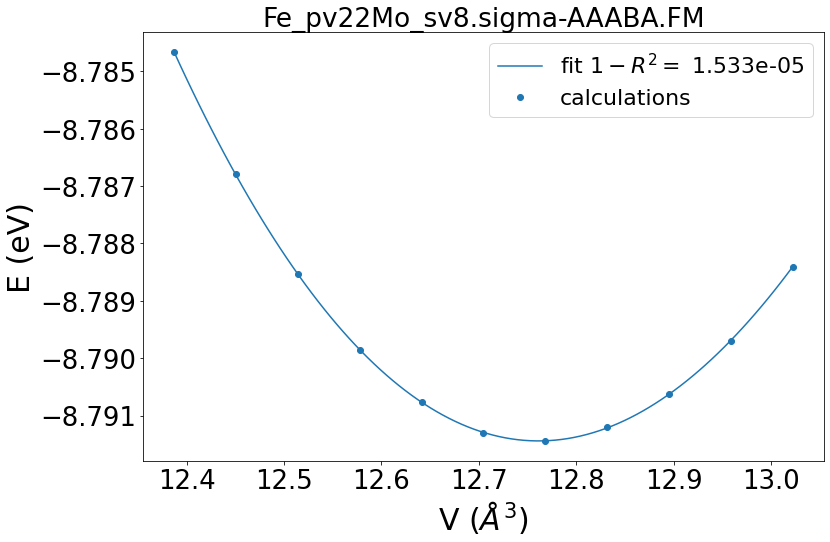

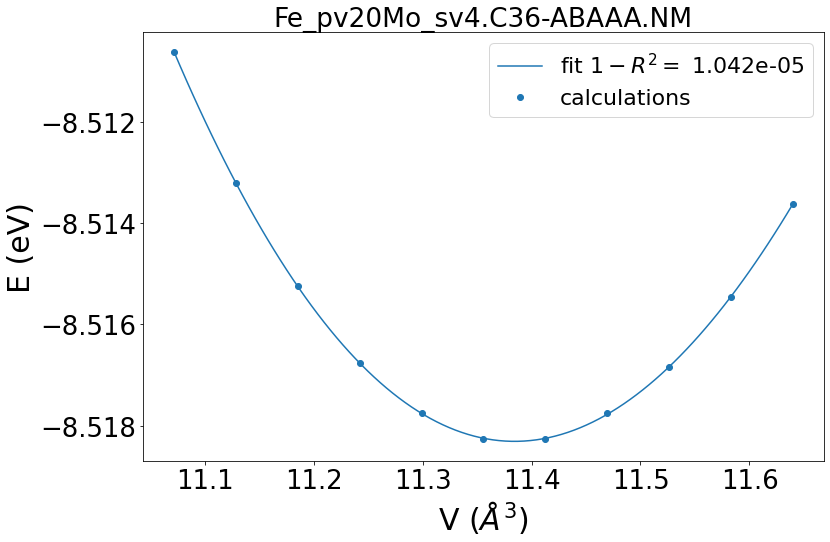

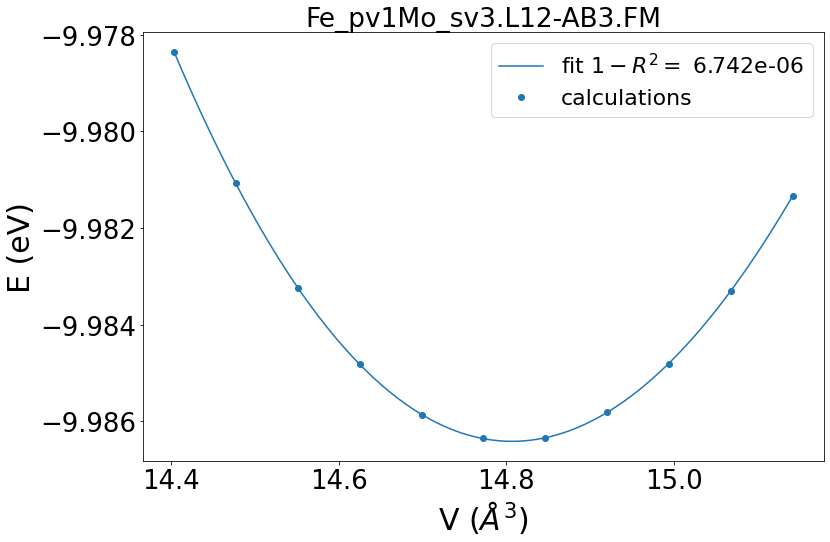

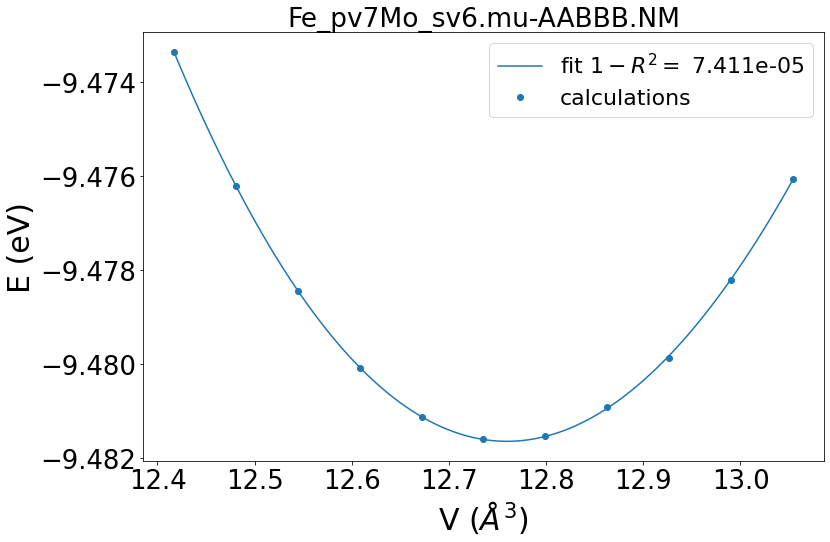

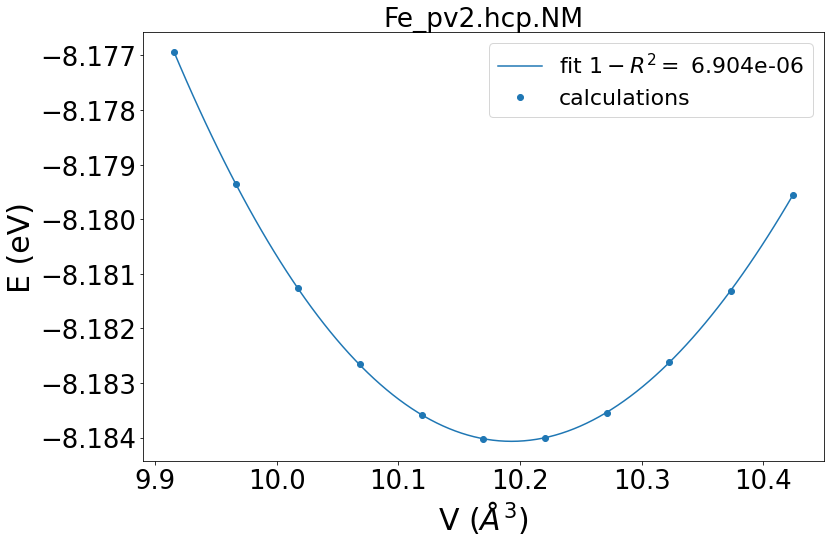

In [104]:
figurecollection, axcollection  = plot_curves(sample_good, sample_good_fit, sample_good_r2)

In [105]:
sample_max_B0 = fixedGoodBS.query('nelem == 1').B0.idxmax()

In [106]:
sample_min_B0 = fixedGoodBS.query('nelem == 1').B0.idxmin()

In [107]:
fixedGoodBS.B0[[sample_min_B0]]

Fe_pv29.chi.FM    141.243922
Name: B0, dtype: float64

In [108]:
fixedGoodBS.B0[[sample_max_B0]]

Fe_pv2.hcp.NM    287.828951
Name: B0, dtype: float64

In [109]:
theminbo = EVcurves_df.loc[sample_min_B0].dropna()

In [110]:
theminbo[0]

{'evcurve': {'V': array([12.20209483, 12.14257241, 12.08305   , 12.02352759, 11.96400517,
         11.90448276, 11.84496034, 11.78543793, 11.72591552, 11.6663931 ,
         11.60687069]),
  'E': array([-8.13550931, -8.13647862, -8.13713379, -8.13749276, -8.13550069,
         -8.13721655, -8.13661655, -8.13563345, -8.13467793, -8.13458207,
         -8.13454448])},
 'ev_fit_results': {'E_murn': -8.137048,
  'V_murn': 12.050793,
  'B_murn': 152.259441,
  'Bdev_murn': -117.055042},
 'r2': 0.7439803024901831,
 'fit': array([ -8.13707309, 151.41578785, -49.39795564,  12.02569393]),
 'IsGood': False,
 'calc_param': 'xc=PBE-PAW.E=450.dk=0.020'}

In [111]:
selection = ((fixedGoodBS.B0>=fixedGoodBS.B0[sample_min_B0]) & (fixedGoodBS.B0<=fixedGoodBS.B0[sample_max_B0]))

In [112]:
selection.sum()

292

In [113]:
selection_stricter = ((fixedGoodBS.B0>1.1*fixedGoodBS.B0[sample_min_B0]) & (fixedGoodBS.B0<0.90*fixedGoodBS.B0[sample_max_B0]) &
                     (list(R2[sample_max_B0].values())[0] > 0.998))

In [114]:
selection_stricter

Fe_pv4Mo_sv20.C36-ABBBB.FM          True
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM     True
Fe_pv2Mo_sv11.mu-BBABB.FM           True
Fe_pv8Mo_sv22.sigma-BBBAB.NM       False
Fe_pv2Mo_sv11.mu-BBBBA.NM           True
                                   ...  
Fe_pv6.C15.FM                      False
Mo_sv1.bcc.NM                       True
Mo_sv8.A15.NM                       True
Mo_sv1.fcc.NM                       True
Mo_sv6.C15.NM                       True
Name: B0, Length: 292, dtype: bool

In [115]:
samples_wrong_b0 = fixedGoodBS[~selection].index

In [116]:
len(samples_wrong_b0)

0

<AxesSubplot:ylabel='Frequency'>

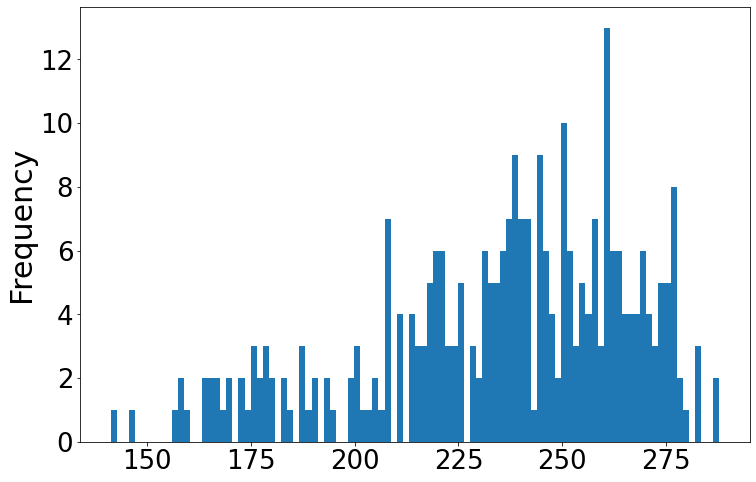

In [117]:
fixedGoodBS.B0.plot.hist(bins=100)

In [118]:
curve_wrong_b0 = EVcurves[samples_wrong_b0]

In [119]:
r2_wrong_b0 = R2[samples_wrong_b0]

In [120]:
fits_wrong_b0 = Fits[samples_wrong_b0]

In [121]:
curve_wrong_b0

Series([], dtype: object)

In [122]:
figurecollection, axcollection  = plot_curves(curve_wrong_b0, fits_wrong_b0, r2_wrong_b0)
for ax, index  in zip(axcollection, samples_wrong_b0):
    title=ax.get_title()
    title += f'$B_0$ = {fixedGoodBS.B0[index]}'
    ax.set_title(title)

In [123]:
GoodBS.drop(index=samples_wrong_b0, inplace=True)

In [124]:
samples_low_b0 = GoodBS.query('B0 < 150').index

In [125]:
curve_low_b0 = EVcurves[samples_low_b0]

In [126]:
r2_low_b0 = R2[samples_low_b0]

In [127]:
fits_low_b0 = Fits[samples_low_b0]

In [128]:
figurecollection, axcollection  = plot_curves(curve_low_b0, fits_low_b0, r2_low_b0)
for ax, index  in zip(axcollection, samples_low_b0):
    title=ax.get_title()
    title += f'$B_0$ = {GoodBS.B0[index]}'
    ax.set_title(title)

# Save for later use 

In [129]:
#curatedbs = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')
#GoodBS.to_pickle(curatedbs)

<AxesSubplot:>

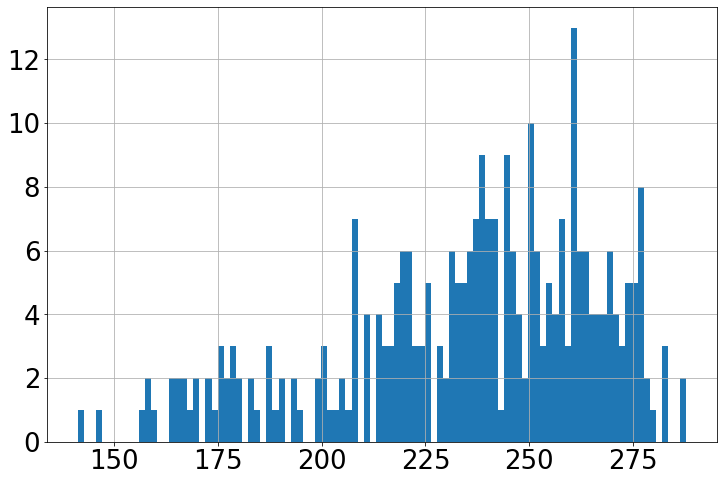

In [130]:
fixedGoodBS.B0.hist(bins=100)